In [9]:
# =========================
# Imports & Global Config
# =========================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("inline")
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import (
    accuracy_score, recall_score, roc_auc_score,
    roc_curve, confusion_matrix
)

# XGBoost (optional, fallback to GradientBoosting)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("Warning: xgboost not found, using GradientBoostingClassifier instead")

warnings.filterwarnings("ignore")
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")

# ---------- Global Variables ----------
RANDOM_STATE = 42
CORR_THRESHOLD = 0.9
K_BEST = 20
RF_TOP_N = 20
XGB_TOP_N = 20
SVM_RFE_TOP_N = 20
N_BOOTSTRAP = 1000

TASK_DIR = r"D:\Research\medical-ml-learning\Task\Task 02"
FIG_DIR = os.path.join(TASK_DIR, "figures_fs")
os.makedirs(FIG_DIR, exist_ok=True)
CSV_PATH = os.path.join(TASK_DIR, "radiomics_features.csv")

# ---------- Unified Colors ----------
METHOD_COLORS = {
    "No Selection":        "#888780",
    "Pearson+SelectKBest": "#0F6E56",
    "LASSO":               "#BA7517",
    "RF Importance":       "#534AB7",
    "XGBoost Importance":  "#C0392B",
    "SVM-RFE":             "#1A5276",
}

# ---------- Feature Family Mapping ----------
FAMILY_PREFIXES = [
    ("original_shape2D", "shape2D"),
    ("original_firstorder", "firstorder"),
    ("original_glcm", "glcm"),
    ("original_glrlm", "glrlm"),
    ("original_glszm", "glszm"),
    ("original_gldm", "gldm"),
    ("original_ngtdm", "ngtdm"),
]
FAMILY_ORDER = ["shape2D", "firstorder", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]

def get_family(feat_name):
    for prefix, name in FAMILY_PREFIXES:
        if feat_name.startswith(prefix):
            return name
    return "other"

def short_name(feat_name):
    return feat_name.replace("original_", "")

def make_classifier(model_name="LR"):
    """Create a classifier with consistent settings."""
    if model_name == "LR":
        return LogisticRegression(
            class_weight="balanced", max_iter=10000,
            random_state=RANDOM_STATE
        )
    elif model_name == "SVM":
        return SVC(
            kernel="rbf", class_weight="balanced",
            probability=True, random_state=RANDOM_STATE
        )
    elif model_name == "RF":
        return RandomForestClassifier(
            class_weight="balanced", n_estimators=200, max_depth=10,
            random_state=RANDOM_STATE
        )
    elif model_name == "XGBoost":
        if HAS_XGB:
            return XGBClassifier(
                n_estimators=200, max_depth=6, learning_rate=0.1,
                eval_metric="logloss",
                random_state=RANDOM_STATE
            )
        else:
            return GradientBoostingClassifier(
                n_estimators=200, max_depth=6, learning_rate=0.1,
                random_state=RANDOM_STATE
            )

CLASSIFIER_LABELS = {
    "LR": "Logistic Regression",
    "SVM": "SVM (RBF)",
    "RF": "Random Forest",
    "XGBoost": "XGBoost" if HAS_XGB else "Gradient Boosting",
}

print("Environment configured")
print(f"XGBoost available: {HAS_XGB}")
print(f"CSV path: {CSV_PATH}")
print(f"Output dir: {FIG_DIR}")

Environment configured
XGBoost available: True
CSV path: D:\Research\medical-ml-learning\Task\Task 02\radiomics_features.csv
Output dir: D:\Research\medical-ml-learning\Task\Task 02\figures_fs


In [11]:
# =========================
# Load CSV & Preprocess
# =========================

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        f"CSV not found: {CSV_PATH}\n"
        "Please run task.ipynb first to generate radiomics_features.csv"
    )

df_features = pd.read_csv(CSV_PATH)
print(f"Loaded: {CSV_PATH}")
print(f"Shape: {df_features.shape}")

feature_cols = [c for c in df_features.columns
                if c not in ("sample_id", "label", "label_name")]
print(f"Total features: {len(feature_cols)}")
print(f"Samples: {len(df_features)}")
print()
print(df_features["label_name"].value_counts())

# Feature family overview
print("\nFeature families:")
family_total = {}
for col in feature_cols:
    fam = get_family(col)
    family_total[fam] = family_total.get(fam, 0) + 1
for fam in FAMILY_ORDER:
    print(f"  {fam:12s}: {family_total.get(fam, 0)} dims")
print(f"  {'Total':12s}: {sum(family_total.values())} dims")

# Train/Test split
X = df_features[feature_cols].values
y = df_features["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"\nTrain: {X_train.shape[0]} (benign={np.sum(y_train==0)}, malignant={np.sum(y_train==1)})")
print(f"Test:  {X_test.shape[0]}  (benign={np.sum(y_test==0)}, malignant={np.sum(y_test==1)})")

# Standardization (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nPreprocessing complete.")

Loaded: D:\Research\medical-ml-learning\Task\Task 02\radiomics_features.csv
Shape: (647, 105)
Total features: 102
Samples: 647

label_name
benign       437
malignant    210
Name: count, dtype: int64

Feature families:
  shape2D     : 9 dims
  firstorder  : 18 dims
  glcm        : 24 dims
  glrlm       : 16 dims
  glszm       : 16 dims
  gldm        : 14 dims
  ngtdm       : 5 dims
  Total       : 102 dims

Train: 517 (benign=349, malignant=168)
Test:  130  (benign=88, malignant=42)

Preprocessing complete.


In [12]:
# =========================
# Q1: No Selection Baseline (102 features -> Logistic Regression)
# =========================

lr_baseline = make_classifier("LR")
lr_baseline.fit(X_train_scaled, y_train)

y_pred = lr_baseline.predict(X_test_scaled)
y_prob = lr_baseline.predict_proba(X_test_scaled)[:, 1]

auc_val = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)
sens = recall_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
spec = tn / (tn + fp)

# Bootstrap CI
rng = np.random.RandomState(RANDOM_STATE)
aucs_boot = []
for _ in range(N_BOOTSTRAP):
    idx = rng.choice(len(y_test), size=len(y_test), replace=True)
    if len(np.unique(y_test[idx])) < 2:
        continue
    aucs_boot.append(roc_auc_score(y_test[idx], y_prob[idx]))
auc_low, auc_high = np.percentile(aucs_boot, [2.5, 97.5])

# 5-fold CV
cv_scores = cross_val_score(
    lr_baseline, X_train_scaled, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc"
)

print("=" * 60)
print("Q1: No Selection Baseline (102 features -> Logistic Regression)")
print("=" * 60)
print(f"  AUC:         {auc_val:.4f}  (95% CI: [{auc_low:.3f}, {auc_high:.3f}])")
print(f"  Accuracy:    {acc:.4f}")
print(f"  Sensitivity: {sens:.4f}")
print(f"  Specificity: {spec:.4f}")
print(f"  5-fold CV AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print()
print("This is our baseline. All subsequent methods will compare against this.")

# Store results
all_results = {}
all_results["No Selection"] = {
    "n_features": len(feature_cols),
    "features": list(feature_cols),
    "auc": auc_val, "auc_low": auc_low, "auc_high": auc_high,
    "accuracy": acc, "sensitivity": sens, "specificity": spec,
    "cv_auc": cv_scores.mean(), "cv_std": cv_scores.std(),
    "y_prob": y_prob,
}

Q1: No Selection Baseline (102 features -> Logistic Regression)
  AUC:         0.9646  (95% CI: [0.925, 0.994])
  Accuracy:    0.9231
  Sensitivity: 0.9524
  Specificity: 0.9091
  5-fold CV AUC: 0.9721 +/- 0.0114

This is our baseline. All subsequent methods will compare against this.


In [13]:
# =========================
# Q2: Apply 5 Feature Selection Methods
# =========================

selected_features = {}  # method_name -> list of selected feature names

# --- Method 1: Pearson Correlation + SelectKBest (two-step) ---
print("--- Pearson + SelectKBest (Two-Step) ---")
# Step 1: Pearson correlation filtering
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
corr_train = X_train_df.corr().abs()
upper_mask = np.triu(np.ones(corr_train.shape), k=1).astype(bool)
upper = corr_train.where(upper_mask)
to_drop = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]
pearson_remaining = [c for c in feature_cols if c not in to_drop]
print(f"  Step 1 (Pearson |r|>{CORR_THRESHOLD}): {len(feature_cols)} -> {len(pearson_remaining)} (removed {len(to_drop)})")

# Step 2: SelectKBest on remaining features
pearson_idx = [feature_cols.index(c) for c in pearson_remaining]
k_actual = min(K_BEST, len(pearson_remaining))
selector_pk = SelectKBest(score_func=f_classif, k=k_actual)
selector_pk.fit(X_train_scaled[:, pearson_idx], y_train)
pk_mask = selector_pk.get_support()
pkbest_selected = [pearson_remaining[i] for i in range(len(pearson_remaining)) if pk_mask[i]]
selected_features["Pearson+SelectKBest"] = pkbest_selected
print(f"  Step 2 (SelectKBest k={k_actual}): -> {len(pkbest_selected)} features")
print(f"  Example: {[short_name(f) for f in pkbest_selected[:5]]}")

# --- Method 2: LASSO (L1-regularized Logistic Regression) ---
print()
print("--- LASSO (L1 Logistic Regression) ---")
lasso_cv = LogisticRegressionCV(
    Cs=np.logspace(-3, 1, 20),
    penalty="l1", solver="saga",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    max_iter=10000, class_weight="balanced",
    random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1
)
lasso_cv.fit(X_train_scaled, y_train)
lasso_coefs = lasso_cv.coef_[0]
lasso_selected = [feature_cols[i] for i in range(len(feature_cols)) if abs(lasso_coefs[i]) > 1e-10]

if len(lasso_selected) == 0:
    print("  Warning: LASSO selected 0 features, falling back to top-20 by |coef|")
    lasso_ranked = sorted(range(len(feature_cols)), key=lambda i: -abs(lasso_coefs[i]))
    lasso_selected = [feature_cols[i] for i in lasso_ranked[:20]]

selected_features["LASSO"] = lasso_selected
print(f"  Optimal C: {lasso_cv.C_[0]:.4f}")
print(f"  Non-zero coefficients: {len(lasso_selected)}")

# --- Method 3: Random Forest Importance ---
print()
print(f"--- Random Forest Importance (top-{RF_TOP_N}) ---")
rf_for_selection = make_classifier("RF")
rf_for_selection.fit(X_train_scaled, y_train)
rf_importances = rf_for_selection.feature_importances_
rf_ranked = np.argsort(rf_importances)[::-1]
rf_selected = [feature_cols[i] for i in rf_ranked[:RF_TOP_N]]
selected_features["RF Importance"] = rf_selected
print(f"  Selected: {len(rf_selected)} features")
print(f"  Top-3: {[(short_name(feature_cols[i]), f'{rf_importances[i]:.4f}') for i in rf_ranked[:3]]}")

# --- Method 4: XGBoost Importance ---
print()
print(f"--- XGBoost Importance (top-{XGB_TOP_N}) ---")
xgb_for_sel = make_classifier("XGBoost")
xgb_for_sel.fit(X_train_scaled, y_train)
xgb_importances = xgb_for_sel.feature_importances_
xgb_ranked = np.argsort(xgb_importances)[::-1]
xgb_selected = [feature_cols[i] for i in xgb_ranked[:XGB_TOP_N]]
selected_features["XGBoost Importance"] = xgb_selected
print(f"  Selected: {len(xgb_selected)} features")
print(f"  Top-3: {[(short_name(feature_cols[i]), f'{xgb_importances[i]:.4f}') for i in xgb_ranked[:3]]}")

# --- Method 5: SVM-RFE (Recursive Feature Elimination) ---
print()
print(f"--- SVM-RFE (target {SVM_RFE_TOP_N} features) ---")
svc_rfe = LinearSVC(
    class_weight="balanced", max_iter=20000,
    random_state=RANDOM_STATE, dual=False
)
rfe = RFE(estimator=svc_rfe, n_features_to_select=SVM_RFE_TOP_N, step=0.1)
rfe.fit(X_train_scaled, y_train)
rfe_mask = rfe.get_support()
svm_rfe_selected = [feature_cols[i] for i in range(len(feature_cols)) if rfe_mask[i]]
selected_features["SVM-RFE"] = svm_rfe_selected
print(f"  Selected: {len(svm_rfe_selected)} features")
print(f"  Ranking done in {rfe.n_features_in_ - SVM_RFE_TOP_N} elimination steps")

# --- Summary table ---
print()
print("=" * 55)
print("Feature Selection Summary")
print("=" * 55)
print(f"{'Method':<22s} {'Features':>8s}")
print("-" * 35)
print(f"{'No Selection':<22s} {len(feature_cols):>8d}")
for method, feats in selected_features.items():
    print(f"{method:<22s} {len(feats):>8d}")
print("=" * 55)

--- Pearson + SelectKBest (Two-Step) ---
  Step 1 (Pearson |r|>0.9): 102 -> 36 (removed 66)
  Step 2 (SelectKBest k=20): -> 20 features
  Example: ['shape2D_Elongation', 'shape2D_MajorAxisLength', 'shape2D_MeshSurface', 'shape2D_PerimeterSurfaceRatio', 'shape2D_Sphericity']

--- LASSO (L1 Logistic Regression) ---
  Optimal C: 6.1585
  Non-zero coefficients: 97

--- Random Forest Importance (top-20) ---
  Selected: 20 features
  Top-3: [('shape2D_Sphericity', '0.1111'), ('shape2D_Elongation', '0.0494'), ('shape2D_MinorAxisLength', '0.0478')]

--- XGBoost Importance (top-20) ---
  Selected: 20 features
  Top-3: [('shape2D_Elongation', '0.0933'), ('shape2D_Sphericity', '0.0720'), ('firstorder_RobustMeanAbsoluteDeviation', '0.0613')]

--- SVM-RFE (target 20 features) ---
  Selected: 20 features
  Ranking done in 82 elimination steps

Feature Selection Summary
Method                 Features
-----------------------------------
No Selection                102
Pearson+SelectKBest          20


Q3: Feature Overlap Analysis

Pairwise Jaccard similarity (intersection / union):
                        Pearson+Select           LASSO   RF Importance  XGBoost Import         SVM-RFE
Pearson+SelectKBest              1.000           0.206           0.379           0.143           0.111
LASSO                            0.206           1.000           0.206           0.206           0.206
RF Importance                    0.379           0.206           1.000           0.212           0.176
XGBoost Importance               0.143           0.206           0.212           1.000           0.176
SVM-RFE                          0.111           0.206           0.176           0.176           1.000


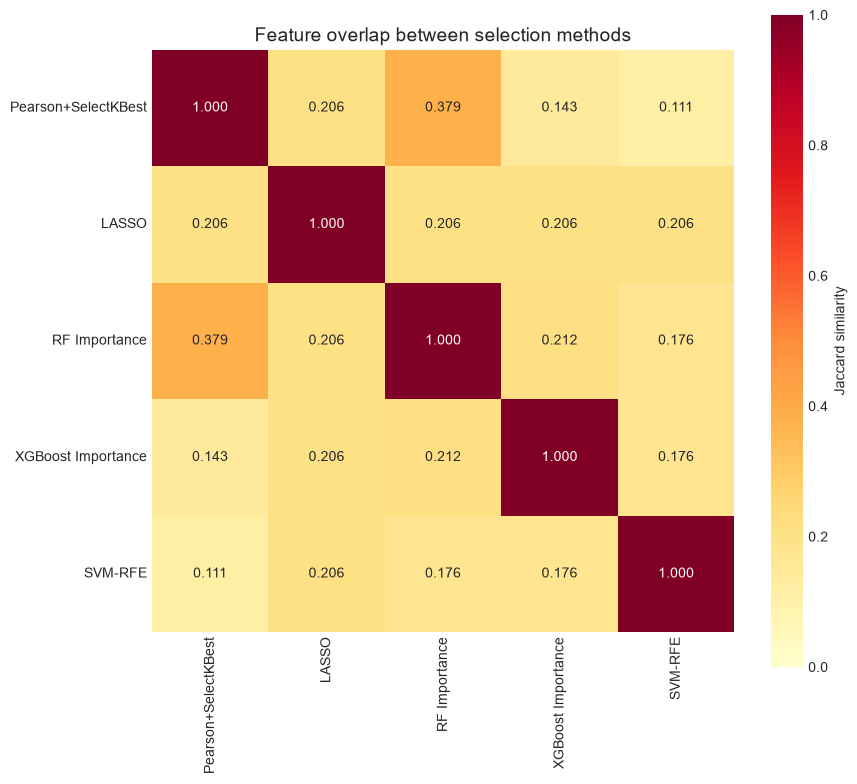


Consensus features (selected by all 5 methods): 2
  shape2D_Elongation
  shape2D_Sphericity

Method-unique features (selected by only 1 method):
  Pearson+SelectKBest: 0 features
  LASSO: 45 features
    firstorder_10Percentile
    firstorder_Maximum
    firstorder_Mean
    firstorder_Minimum
    firstorder_Variance
    ... and 40 more
  RF Importance: 0 features
  XGBoost Importance: 0 features
  SVM-RFE: 0 features


In [20]:
# =========================
# Q3: Feature Overlap Analysis
# =========================

method_names = list(selected_features.keys())
n_methods = len(method_names)

print("=" * 60)
print("Q3: Feature Overlap Analysis")
print("=" * 60)

# --- Pairwise Jaccard similarity ---
jaccard_matrix = np.zeros((n_methods, n_methods))
for i, m1 in enumerate(method_names):
    for j, m2 in enumerate(method_names):
        s1, s2 = set(selected_features[m1]), set(selected_features[m2])
        if len(s1 | s2) > 0:
            jaccard_matrix[i, j] = len(s1 & s2) / len(s1 | s2)

print()
print("Pairwise Jaccard similarity (intersection / union):")
print(f"{'':22s}", end="")
for m in method_names:
    print(f"{m[:14]:>16s}", end="")
print()
for i, m1 in enumerate(method_names):
    print(f"{m1:22s}", end="")
    for j in range(n_methods):
        print(f"{jaccard_matrix[i, j]:>16.3f}", end="")
    print()

# Heatmap
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(jaccard_matrix, annot=True, fmt=".3f", cmap="YlOrRd",
            xticklabels=method_names, yticklabels=method_names,
            vmin=0, vmax=1, square=True, ax=ax,
            cbar_kws={"label": "Jaccard similarity"})
ax.set_title("Feature overlap between selection methods", fontsize=14, fontweight=500)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "q3_jaccard_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- Feature x Method table ---
all_selected = set()
for feats in selected_features.values():
    all_selected.update(feats)

feature_method_count = {}
for feat in all_selected:
    count = sum(1 for m in method_names if feat in selected_features[m])
    feature_method_count[feat] = count

# Consensus features
consensus = [f for f, c in feature_method_count.items() if c == n_methods]
print()
print(f"Consensus features (selected by all {n_methods} methods): {len(consensus)}")
for feat in sorted(consensus, key=lambda f: short_name(f)):
    print(f"  {short_name(feat)}")

# Method-unique features
print()
print("Method-unique features (selected by only 1 method):")
for m in method_names:
    u = [f for f in selected_features[m] if feature_method_count[f] == 1]
    print(f"  {m}: {len(u)} features")
    for f in u[:5]:
        print(f"    {short_name(f)}")
    if len(u) > 5:
        print(f"    ... and {len(u)-5} more")



Q4 Phase 1: Performance Comparison (Fixed: Logistic Regression)

Pearson+SelectKBest (20 features):
  AUC: 0.9654  (95% CI: [0.927, 0.993])
  Accuracy: 0.9385  Sens: 0.9524  Spec: 0.9318
  5-fold CV AUC: 0.9760 +/- 0.0084

LASSO (97 features):
  AUC: 0.9646  (95% CI: [0.925, 0.994])
  Accuracy: 0.9231  Sens: 0.9524  Spec: 0.9091
  5-fold CV AUC: 0.9722 +/- 0.0113

RF Importance (20 features):
  AUC: 0.9605  (95% CI: [0.915, 0.994])
  Accuracy: 0.9462  Sens: 0.9762  Spec: 0.9318
  5-fold CV AUC: 0.9747 +/- 0.0098

XGBoost Importance (20 features):
  AUC: 0.9659  (95% CI: [0.925, 0.995])
  Accuracy: 0.9308  Sens: 0.9762  Spec: 0.9091
  5-fold CV AUC: 0.9773 +/- 0.0091

SVM-RFE (20 features):
  AUC: 0.9594  (95% CI: [0.914, 0.992])
  Accuracy: 0.9231  Sens: 0.9524  Spec: 0.9091
  5-fold CV AUC: 0.9847 +/- 0.0060

Method                 #Feat      AUC             95% CI     Acc    Sens    Spec       CV AUC
------------------------------------------------------------------------------------

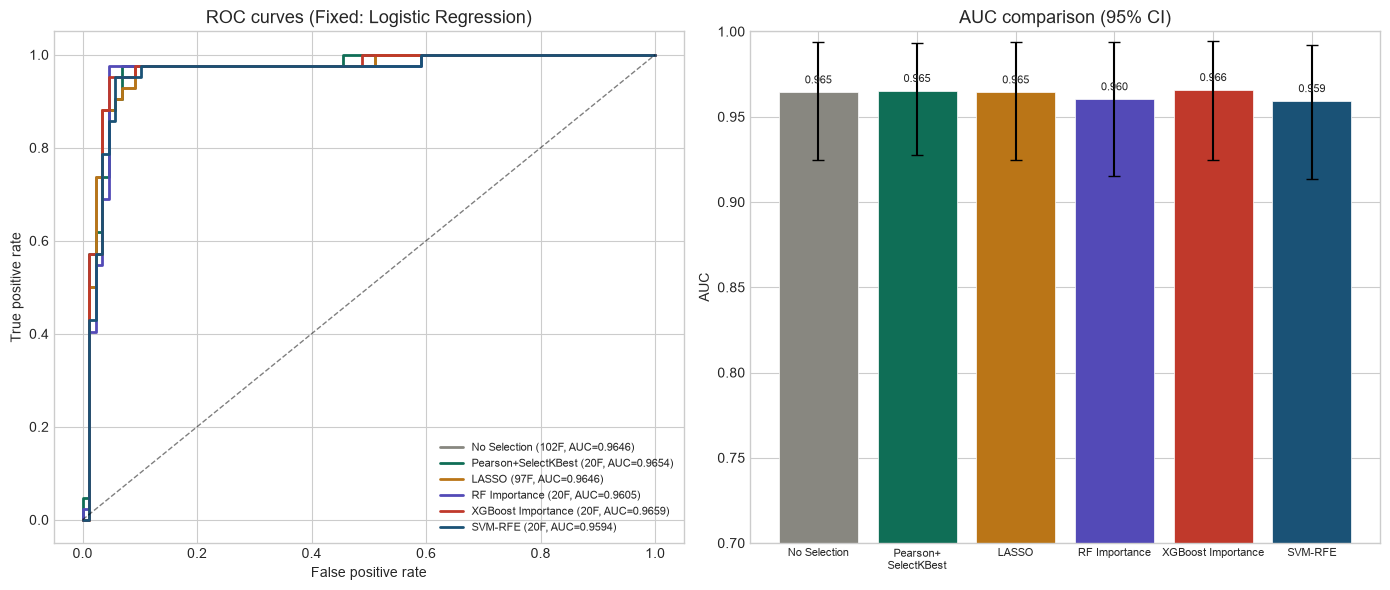


Best method (by test AUC): XGBoost Importance (AUC=0.9659, 20 features)


In [19]:
# =========================
# Q4 Phase 1: Performance Comparison (Fixed Model: Logistic Regression)
# =========================

print("=" * 60)
print("Q4 Phase 1: Performance Comparison (Fixed: Logistic Regression)")
print("=" * 60)

perf_results = {"No Selection": all_results["No Selection"]}

# For each selection method, train LR on selected features
for method, feats in selected_features.items():
    feat_idx = [feature_cols.index(f) for f in feats]
    X_tr = X_train_scaled[:, feat_idx]
    X_te = X_test_scaled[:, feat_idx]

    lr = make_classifier("LR")
    lr.fit(X_tr, y_train)

    y_pred = lr.predict(X_te)
    y_prob = lr.predict_proba(X_te)[:, 1]

    auc_val = roc_auc_score(y_test, y_prob)
    acc = accuracy_score(y_test, y_pred)
    sens = recall_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    spec = tn / (tn + fp)

    # Bootstrap CI
    rng_bs = np.random.RandomState(RANDOM_STATE)
    aucs_boot = []
    for _ in range(N_BOOTSTRAP):
        idx = rng_bs.choice(len(y_test), size=len(y_test), replace=True)
        if len(np.unique(y_test[idx])) < 2:
            continue
        aucs_boot.append(roc_auc_score(y_test[idx], y_prob[idx]))
    auc_low, auc_high = np.percentile(aucs_boot, [2.5, 97.5])

    # 5-fold CV
    cv_scores = cross_val_score(
        lr, X_tr, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc"
    )

    perf_results[method] = {
        "n_features": len(feats),
        "features": feats,
        "auc": auc_val, "auc_low": auc_low, "auc_high": auc_high,
        "accuracy": acc, "sensitivity": sens, "specificity": spec,
        "cv_auc": cv_scores.mean(), "cv_std": cv_scores.std(),
        "y_prob": y_prob,
    }

    print()
    print(f"{method} ({len(feats)} features):")
    print(f"  AUC: {auc_val:.4f}  (95% CI: [{auc_low:.3f}, {auc_high:.3f}])")
    print(f"  Accuracy: {acc:.4f}  Sens: {sens:.4f}  Spec: {spec:.4f}")
    print(f"  5-fold CV AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# Summary table
print()
print("=" * 85)
print(f"{'Method':<22s} {'#Feat':>5s} {'AUC':>8s} {'95% CI':>18s} "
      f"{'Acc':>7s} {'Sens':>7s} {'Spec':>7s} {'CV AUC':>12s}")
print("-" * 85)
for method, res in perf_results.items():
    ci = f"[{res['auc_low']:.3f}, {res['auc_high']:.3f}]"
    cv_str = f"{res['cv_auc']:.4f}+/-{res['cv_std']:.3f}"
    print(f"{method:<22s} {res['n_features']:>5d} {res['auc']:>8.4f} {ci:>18s} "
          f"{res['accuracy']:>7.4f} {res['sensitivity']:>7.4f} {res['specificity']:>7.4f} "
          f"{cv_str:>12s}")
print("=" * 85)

# --- ROC curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for method, res in perf_results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    axes[0].plot(fpr, tpr, color=METHOD_COLORS[method], linewidth=2,
                 label=f"{method} ({res['n_features']}F, AUC={res['auc']:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
axes[0].set_title("ROC curves (Fixed: Logistic Regression)", fontsize=13, fontweight=500)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend(fontsize=8)

# AUC comparison bar chart
methods_list = list(perf_results.keys())
aucs = [perf_results[m]["auc"] for m in methods_list]
ci_lows = [perf_results[m]["auc"] - perf_results[m]["auc_low"] for m in methods_list]
ci_highs = [perf_results[m]["auc_high"] - perf_results[m]["auc"] for m in methods_list]
colors = [METHOD_COLORS[m] for m in methods_list]

bars = axes[1].bar(range(len(methods_list)), aucs,
                    yerr=[ci_lows, ci_highs],
                    color=colors, edgecolor="white", linewidth=0.5, capsize=4)
axes[1].set_xticks(range(len(methods_list)))
axes[1].set_xticklabels([m.replace("+", "+\n") for m in methods_list], fontsize=8, rotation=0)
axes[1].set_ylabel("AUC")
axes[1].set_title("AUC comparison (95% CI)", fontsize=13, fontweight=500)
axes[1].set_ylim(0.7, 1.0)
for bar, val in zip(bars, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", fontsize=8, fontweight=500)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "q4_phase1_performance.png"), dpi=150, bbox_inches="tight")
plt.show()



# Identify best method
best_method = max(perf_results.keys(), key=lambda m: perf_results[m]["auc"])
print(f"\nBest method (by test AUC): {best_method} "
      f"(AUC={perf_results[best_method]['auc']:.4f}, "
      f"{perf_results[best_method]['n_features']} features)")

Q4 Phase 2: Classifier Comparison
  Feature set: XGBoost Importance (20 features)

Logistic Regression:
  AUC: 0.9659  (95% CI: [0.925, 0.995])
  Accuracy: 0.9308  Sens: 0.9762  Spec: 0.9091
  5-fold CV AUC: 0.9773 +/- 0.0091

SVM (RBF):
  AUC: 0.9716  (95% CI: [0.923, 0.998])
  Accuracy: 0.9231  Sens: 0.9524  Spec: 0.9091
  5-fold CV AUC: 0.9756 +/- 0.0128

Random Forest:
  AUC: 0.9479  (95% CI: [0.901, 0.983])
  Accuracy: 0.8923  Sens: 0.8095  Spec: 0.9318
  5-fold CV AUC: 0.9613 +/- 0.0284

XGBoost:
  AUC: 0.9719  (95% CI: [0.938, 0.995])
  Accuracy: 0.9385  Sens: 0.9048  Spec: 0.9545
  5-fold CV AUC: 0.9827 +/- 0.0125

Classifier                  AUC             95% CI     Acc    Sens    Spec       CV AUC
--------------------------------------------------------------------------------
Logistic Regression      0.9659     [0.925, 0.995]  0.9308  0.9762  0.9091 0.9773+/-0.009
SVM (RBF)                0.9716     [0.923, 0.998]  0.9231  0.9524  0.9091 0.9756+/-0.013
Random Forest       

findfont: Failed to find font weight 500, now using 400.


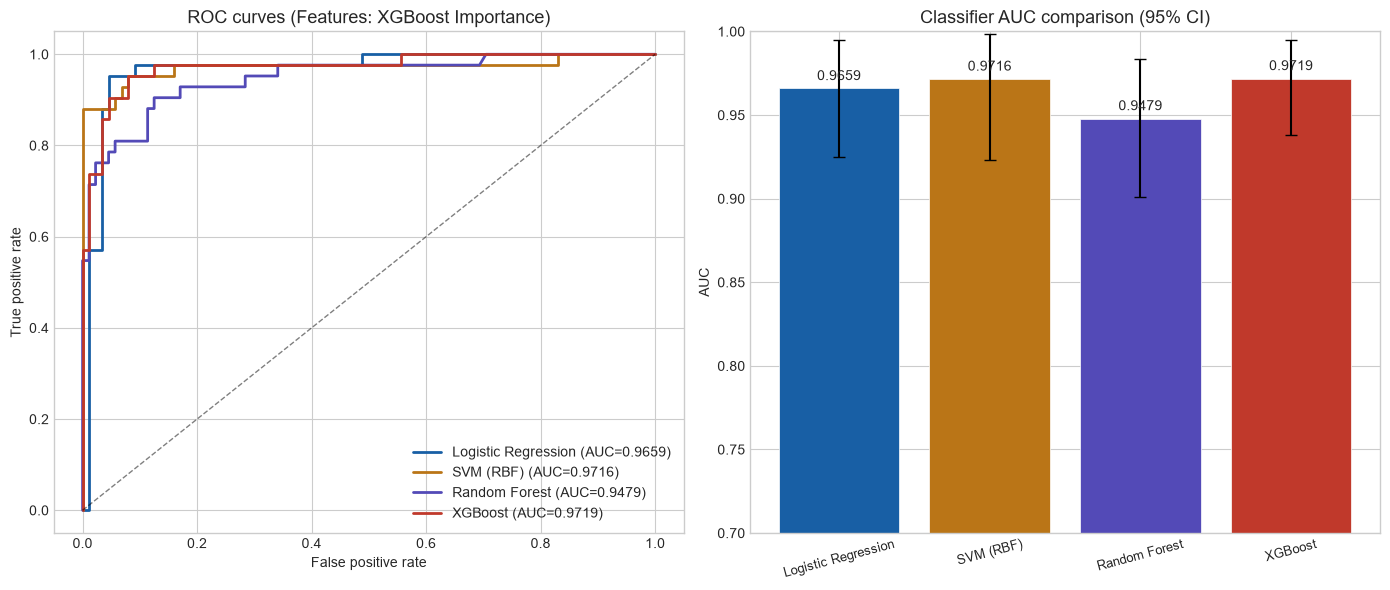


Best classifier: XGBoost (AUC=0.9719)

Final model: XGBoost Importance + XGBoost


In [16]:
# =========================
# Q4 Phase 2: Classifier Comparison (Fixed: Best Feature Set)
# =========================

print("=" * 60)
print(f"Q4 Phase 2: Classifier Comparison")
print(f"  Feature set: {best_method} ({perf_results[best_method]['n_features']} features)")
print("=" * 60)

best_features = perf_results[best_method]["features"]
best_feat_idx = [feature_cols.index(f) for f in best_features]

X_tr_best = X_train_scaled[:, best_feat_idx]
X_te_best = X_test_scaled[:, best_feat_idx]

CLF_COLORS = {
    "LR": "#185FA5",
    "SVM": "#BA7517",
    "RF": "#534AB7",
    "XGBoost": "#C0392B",
}

classifier_results = {}

for clf_key in ["LR", "SVM", "RF", "XGBoost"]:
    clf = make_classifier(clf_key)
    clf.fit(X_tr_best, y_train)

    y_pred = clf.predict(X_te_best)
    y_prob = clf.predict_proba(X_te_best)[:, 1]

    auc_val = roc_auc_score(y_test, y_prob)
    acc = accuracy_score(y_test, y_pred)
    sens = recall_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    spec = tn / (tn + fp)

    # Bootstrap CI
    rng_bs = np.random.RandomState(RANDOM_STATE)
    aucs_boot = []
    for _ in range(N_BOOTSTRAP):
        idx = rng_bs.choice(len(y_test), size=len(y_test), replace=True)
        if len(np.unique(y_test[idx])) < 2:
            continue
        aucs_boot.append(roc_auc_score(y_test[idx], y_prob[idx]))
    auc_low, auc_high = np.percentile(aucs_boot, [2.5, 97.5])

    # 5-fold CV
    cv_scores = cross_val_score(
        clf, X_tr_best, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc"
    )

    classifier_results[clf_key] = {
        "label": CLASSIFIER_LABELS[clf_key],
        "auc": auc_val, "auc_low": auc_low, "auc_high": auc_high,
        "accuracy": acc, "sensitivity": sens, "specificity": spec,
        "cv_auc": cv_scores.mean(), "cv_std": cv_scores.std(),
        "y_prob": y_prob,
    }

    print()
    print(f"{CLASSIFIER_LABELS[clf_key]}:")
    print(f"  AUC: {auc_val:.4f}  (95% CI: [{auc_low:.3f}, {auc_high:.3f}])")
    print(f"  Accuracy: {acc:.4f}  Sens: {sens:.4f}  Spec: {spec:.4f}")
    print(f"  5-fold CV AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# Summary table
print()
print("=" * 80)
print(f"{'Classifier':<22s} {'AUC':>8s} {'95% CI':>18s} "
      f"{'Acc':>7s} {'Sens':>7s} {'Spec':>7s} {'CV AUC':>12s}")
print("-" * 80)
for clf_key, res in classifier_results.items():
    ci = f"[{res['auc_low']:.3f}, {res['auc_high']:.3f}]"
    cv_str = f"{res['cv_auc']:.4f}+/-{res['cv_std']:.3f}"
    print(f"{res['label']:<22s} {res['auc']:>8.4f} {ci:>18s} "
          f"{res['accuracy']:>7.4f} {res['sensitivity']:>7.4f} {res['specificity']:>7.4f} "
          f"{cv_str:>12s}")
print("=" * 80)

# --- ROC curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for clf_key, res in classifier_results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    axes[0].plot(fpr, tpr, color=CLF_COLORS[clf_key], linewidth=2,
                 label=f"{res['label']} (AUC={res['auc']:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
axes[0].set_title(f"ROC curves (Features: {best_method})", fontsize=13, fontweight=500)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend(fontsize=10)

# AUC bar chart
clf_keys = list(classifier_results.keys())
aucs = [classifier_results[k]["auc"] for k in clf_keys]
ci_lows = [classifier_results[k]["auc"] - classifier_results[k]["auc_low"] for k in clf_keys]
ci_highs = [classifier_results[k]["auc_high"] - classifier_results[k]["auc"] for k in clf_keys]
colors = [CLF_COLORS[k] for k in clf_keys]

bars = axes[1].bar(range(len(clf_keys)), aucs,
                    yerr=[ci_lows, ci_highs],
                    color=colors, edgecolor="white", linewidth=0.5, capsize=4)
axes[1].set_xticks(range(len(clf_keys)))
axes[1].set_xticklabels([classifier_results[k]["label"] for k in clf_keys], fontsize=9, rotation=15)
axes[1].set_ylabel("AUC")
axes[1].set_title("Classifier AUC comparison (95% CI)", fontsize=13, fontweight=500)
axes[1].set_ylim(0.7, 1.0)
for bar, val in zip(bars, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.4f}", ha="center", fontsize=10, fontweight=500)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "q4_phase2_classifier_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

# Identify best classifier
best_clf = max(classifier_results.keys(), key=lambda k: classifier_results[k]["auc"])
print(f"\nBest classifier: {classifier_results[best_clf]['label']} "
      f"(AUC={classifier_results[best_clf]['auc']:.4f})")
print(f"\nFinal model: {best_method} + {classifier_results[best_clf]['label']}")

Q5: Feature Family Distribution by Selection Method

Family       Total     Pearson+SK          LASSO             RF        XGBoost        SVM-RFE
-------------------------------------------------------------------------------------
shape2D          9     5 ( 56%)         9 (100%)         8 ( 89%)         4 ( 44%)         5 ( 56%)    
firstorder      18     4 ( 22%)        17 ( 94%)         4 ( 22%)         5 ( 28%)         3 ( 17%)    
glcm            24     1 (  4%)        21 ( 88%)         0 (  0%)         5 ( 21%)         5 ( 21%)    
glrlm           16     6 ( 38%)        16 (100%)         3 ( 19%)         3 ( 19%)         2 ( 12%)    
glszm           16     0 (  0%)        16 (100%)         3 ( 19%)         0 (  0%)         2 ( 12%)    
gldm            14     1 (  7%)        13 ( 93%)         0 (  0%)         2 ( 14%)         3 ( 21%)    
ngtdm            5     3 ( 60%)         5 (100%)         2 ( 40%)         1 ( 20%)         0 (  0%)    


findfont: Failed to find font weight 500, now using 400.


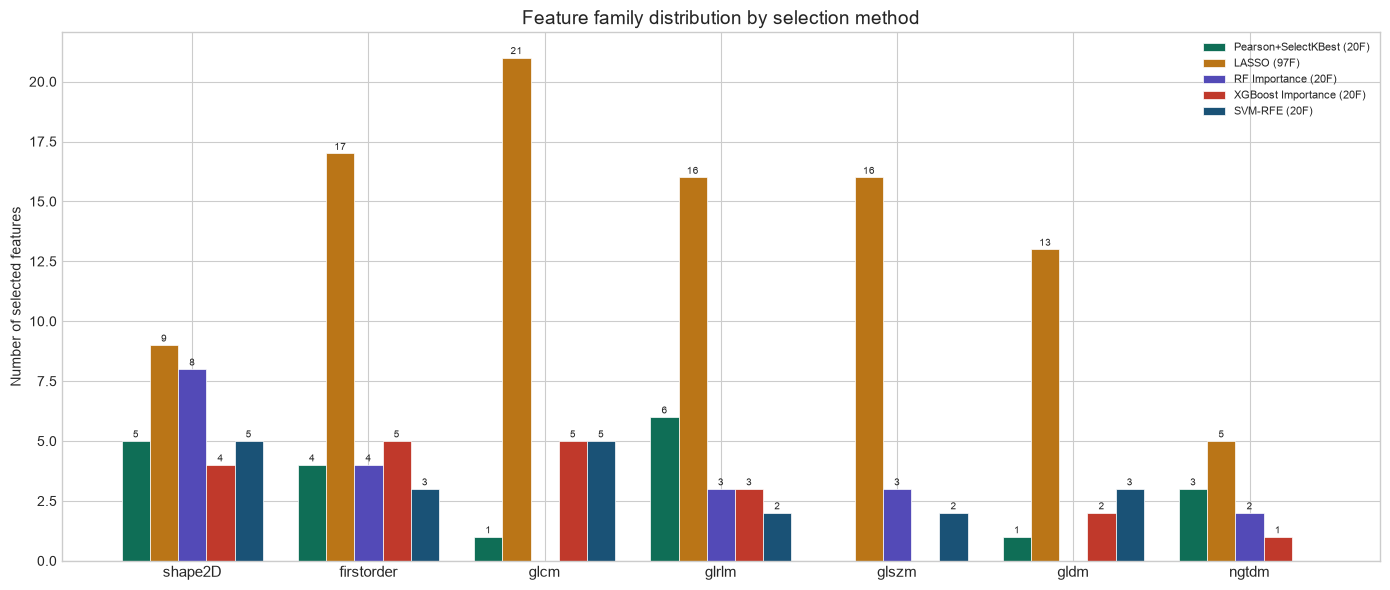

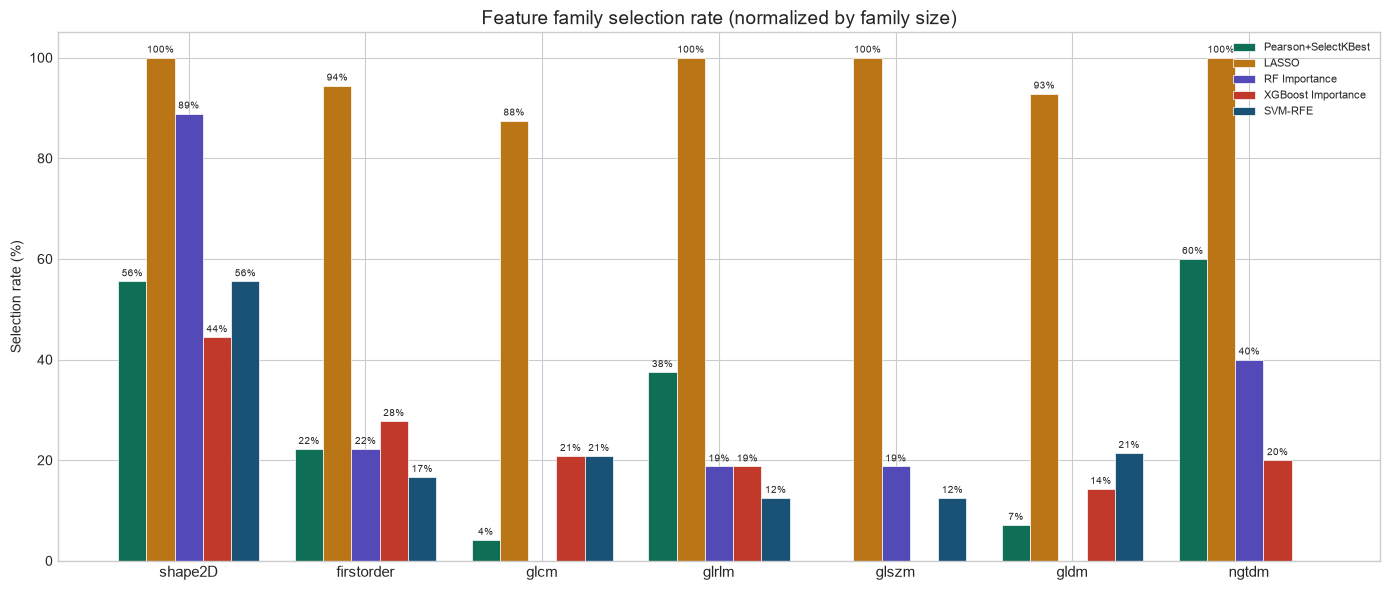


Consensus features (selected by all 5 methods) by family:
  shape2D     : 2 / 9
  firstorder  : 0 / 18
  glcm        : 0 / 24
  glrlm       : 0 / 16
  glszm       : 0 / 16
  gldm        : 0 / 14
  ngtdm       : 0 / 5
  Total       : 2 / 102


In [17]:
# =========================
# Q5: Feature Family Distribution by Selection Method
# =========================

print("=" * 60)
print("Q5: Feature Family Distribution by Selection Method")
print("=" * 60)

# Count features per family for each method
family_method_counts = {}
for method in method_names:
    counts = {fam: 0 for fam in FAMILY_ORDER}
    for feat in selected_features[method]:
        fam = get_family(feat)
        if fam in counts:
            counts[fam] += 1
    family_method_counts[method] = counts

# Print table
print()
print(f"{'Family':<12s} {'Total':>5s}", end="")
for m in method_names:
    short = m.replace("+SelectKBest", "+SK").replace(" Importance", "")
    print(f" {short:>14s}", end="")
print()
print("-" * 85)
for fam in FAMILY_ORDER:
    print(f"{fam:<12s} {family_total.get(fam, 0):>5d}", end="")
    for m in method_names:
        c = family_method_counts[m][fam]
        total = family_total.get(fam, 1)
        pct = c / total * 100
        print(f" {c:>5d} ({pct:>3.0f}%)", end="    ")
    print()

# --- Grouped bar chart (absolute counts) ---
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(FAMILY_ORDER))
n_m = len(method_names)
width = 0.8 / n_m

for i, method in enumerate(method_names):
    vals = [family_method_counts[method][fam] for fam in FAMILY_ORDER]
    offset = (i - n_m/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width,
                  label=f"{method} ({len(selected_features[method])}F)",
                  color=METHOD_COLORS[method], edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                    str(val), ha="center", fontsize=7, fontweight=500)

ax.set_xticks(x)
ax.set_xticklabels(FAMILY_ORDER, fontsize=11)
ax.set_ylabel("Number of selected features")
ax.set_title("Feature family distribution by selection method", fontsize=14, fontweight=500)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "q5_family_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- Percentage view (normalized by family size) ---
fig, ax = plt.subplots(figsize=(14, 6))
for i, method in enumerate(method_names):
    pcts = []
    for fam in FAMILY_ORDER:
        total = family_total.get(fam, 1)
        pcts.append(family_method_counts[method][fam] / total * 100)
    offset = (i - n_m/2 + 0.5) * width
    bars = ax.bar(x + offset, pcts, width,
                  label=method, color=METHOD_COLORS[method], edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, pcts):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f"{val:.0f}%", ha="center", fontsize=7, fontweight=500)

ax.set_xticks(x)
ax.set_xticklabels(FAMILY_ORDER, fontsize=11)
ax.set_ylabel("Selection rate (%)")
ax.set_title("Feature family selection rate (normalized by family size)",
             fontsize=14, fontweight=500)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "q5_family_selection_rate.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- Consensus features by family ---
print()
print(f"Consensus features (selected by all {n_methods} methods) by family:")
consensus_by_family = Counter(get_family(f) for f in consensus)
for fam in FAMILY_ORDER:
    c = consensus_by_family.get(fam, 0)
    t = family_total.get(fam, 0)
    print(f"  {fam:12s}: {c} / {t}")
print(f"  {'Total':12s}: {len(consensus)} / {len(feature_cols)}")